# 🎯 EduSense — SPECIALIST SYSTEM
**King Khalid University — Graduation Project 2025**

### Strategy: Fix engagement and frustration with specialist models
| Emotion | Previous | Approach | Expected |
|---------|----------|----------|----------|
| Engagement | F1=21% | Specialist model (focused on 1 emotion) | F1=50-65% |
| Boredom | F1=17% | Keep ensemble (Acc=76.8%) | Same |
| Confusion | F1=45% | Keep ensemble (Acc=74.2%) | Same |
| Frustration | F1=0% | Specialist model (focused on 1 emotion) | F1=40-55% |

**Target: 73-77% combined accuracy**


## 📦 1. Setup

In [9]:
from google.colab import drive
drive.mount('/content/drive')
import os
if not os.path.exists('/content/daisee_embeddings'):
    !cp -r /content/drive/MyDrive/daisee_embeddings_affectnet /content/daisee_embeddings
    print('✅ Embeddings copied')
else:
    print('✅ Embeddings already local')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Embeddings already local


In [10]:
    !cp -r /content/drive/MyDrive/daisee_embeddings_affectnet /content/daisee_embeddings


## 📚 2. Imports

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import numpy as np
import json, os, random, copy
from collections import defaultdict, Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

EMOTION_NAMES = ['engagement', 'boredom', 'confusion', 'frustration']
THRESHOLDS = {
    'engagement':  3,
    'boredom':     2,
    'confusion':   1,
    'frustration': 1,
}
EMOTION_LOSS_W = [1.0, 1.0, 1.0, 1.0]
print('✅ Imports done')


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB
✅ Imports done


In [22]:
import functools
_original_load = torch.load
torch.load = functools.partial(_original_load, weights_only=False)

In [35]:
#Fix torch.load for PyTorch 2.6+
import functools
_original_load = torch.load
torch.load = functools.partial(_original_load, weights_only=False)

#Verify the fix works
import torch
print(f'PyTorch version: {torch.version}')

#Test save and load a dummy tensor
test_path = '/content/test_save.pth'
torch.save({'test': torch.tensor([1.0, 2.0, 3.0])}, test_path)
loaded = torch.load(test_path)
assert loaded['test'].sum().item() == 6.0
print('✅ torch.save and torch.load working correctly')
print('✅ No more UnpicklingError — safe to train')

PyTorch version: <module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>
✅ torch.save and torch.load working correctly
✅ No more UnpicklingError — safe to train


## 🧠 3. KAN Layer

In [36]:
class KANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_basis=8):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.num_basis    = num_basis
        self.spline_coeffs = nn.Parameter(
            torch.randn(in_features, out_features, num_basis) * 0.1
        )
        self.linear = nn.Linear(in_features, out_features, bias=True)

    def b_spline_basis(self, x):
        x_norm    = torch.tanh(x).unsqueeze(-1)
        basis_idx = torch.linspace(0, np.pi, self.num_basis, device=x.device)
        return torch.cos(x_norm * basis_idx)

    def forward(self, x):
        basis = self.b_spline_basis(x)
        spline_out = torch.einsum('bin,ion->bo', basis, self.spline_coeffs)
        return spline_out + self.linear(x)

print('✅ KANLayer defined')

✅ KANLayer defined


## 🤖 4. Model: Transformer Encoder + KAN + CORAL
**Key upgrade:** Transformer sees ALL 30 frames simultaneously. LSTM forgets early frames. This is the biggest accuracy jump.

In [37]:
class EduSenseTransformer(nn.Module):
    """
    Transformer Encoder + KAN + Binary CORAL
    Input:  (batch, 30, 768) — AffectNet-ViT embeddings
    Output: List of 4 tensors (batch, 1) — binary logit per emotion
    """
    def __init__(
        self,
        embedding_dim = 768,
        num_heads     = 8,
        num_layers    = 2,
        ff_dim        = 1024,
        kan_hidden    = 128,
        num_emotions  = 4,
        dropout       = 0.3
    ):
        super().__init__()

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)

        # Learnable positional encoding for 30 frames + 1 CLS = 31
        self.pos_embed = nn.Parameter(torch.randn(1, 31, embedding_dim) * 0.02)

        self.embed_dropout = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = embedding_dim,
            nhead           = num_heads,
            dim_feedforward = ff_dim,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True   # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            norm=nn.LayerNorm(embedding_dim)
        )

        # KAN for shared feature extraction
        self.kan      = KANLayer(embedding_dim, kan_hidden)
        self.kan_norm = nn.LayerNorm(kan_hidden)
        self.kan_drop = nn.Dropout(dropout)

        # Binary CORAL head per emotion
        self.coral_heads = nn.ModuleList([
            nn.Linear(kan_hidden, 1) for _ in range(num_emotions)
        ])
        for head in self.coral_heads:
            nn.init.xavier_uniform_(head.weight, gain=0.1)
            nn.init.zeros_(head.bias)

    def forward(self, x):
        # x: (batch, 30, 768)
        batch = x.size(0)

        # Prepend CLS token
        cls = self.cls_token.expand(batch, -1, -1)  # (batch, 1, 768)
        x   = torch.cat([cls, x], dim=1)             # (batch, 31, 768)

        # Add positional encoding + dropout
        x = self.embed_dropout(x + self.pos_embed)

        # Transformer
        x = self.transformer(x)   # (batch, 31, 768)

        # Use CLS token output for classification
        cls_out = x[:, 0, :]      # (batch, 768)

        # KAN
        out = self.kan(cls_out)
        out = self.kan_norm(out)
        out = F.relu(out)
        out = self.kan_drop(out)

        return [head(out) for head in self.coral_heads]


# Quick test
_m = EduSenseTransformer().to(device)
_x = torch.randn(2, 30, 768).to(device)
with torch.no_grad():
    _o = _m(_x)
print(f'✅ EduSenseTransformer OK — output: {len(_o)} heads, each {_o[0].shape}')
total = sum(p.numel() for p in _m.parameters())
print(f'   Parameters: {total:,}')
del _m, _x, _o

✅ EduSenseTransformer OK — output: 4 heads, each torch.Size([2, 1])
   Parameters: 8,791,940


## 🎯 5. Loss & Prediction

In [38]:
def coral_loss(logits, labels, class_weights=None):
    """
    Binary focal CORAL loss with class weighting.
    logits: (batch, 1)  labels: (batch,)
    """
    targets = labels.float().unsqueeze(1)

    loss_per_sample = F.binary_cross_entropy_with_logits(
        logits, targets, reduction='none'
    ).squeeze(1)

    # Focal weight — focus on hard samples
    probs   = torch.sigmoid(logits).squeeze(1)
    focal_w = (1 - (probs * labels.float() + (1 - probs) * (1 - labels.float()))) ** 2
    loss_per_sample = loss_per_sample * focal_w

    if class_weights is not None:
        w = torch.tensor(
            [class_weights[int(l.item())] for l in labels],
            dtype=torch.float32, device=labels.device
        )
        return (loss_per_sample * w).mean()

    return loss_per_sample.mean()


def predict(logits, threshold=0.5):
    return (torch.sigmoid(logits) > threshold).long().squeeze(1)


def evaluate(preds, actuals):
    preds   = np.array(preds)
    actuals = np.array(actuals)
    acc  = (preds == actuals).mean() * 100
    tp   = ((preds==1) & (actuals==1)).sum()
    tn   = ((preds==0) & (actuals==0)).sum()
    fp   = ((preds==1) & (actuals==0)).sum()
    fn   = ((preds==0) & (actuals==1)).sum()
    prec = tp / max(tp+fp, 1) * 100
    rec  = tp / max(tp+fn, 1) * 100
    f1   = 2*prec*rec / max(prec+rec, 1e-6)
    return {'acc': acc, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'precision': prec, 'recall': rec, 'f1': f1}

print('✅ Loss, prediction, evaluation defined')

✅ Loss, prediction, evaluation defined


## 💾 6. Dataset with Augmentation

In [39]:
class EmbeddingDataset(Dataset):
    def __init__(self, metadata_list, augment=False):
        self.metadata = metadata_list
        self.augment  = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        item = self.metadata[idx]
        emb  = np.load(item['embedding_path'])           # (30, 768)
        emb  = torch.tensor(emb, dtype=torch.float32)
        emb  = F.normalize(emb, p=2, dim=1)             # L2 norm each frame

        if self.augment:
            # 1. Random frame dropout (10% of frames → zero)
            if torch.rand(1) > 0.5:
                mask = torch.rand(30) > 0.1
                emb[~mask] = 0
            # 2. Small Gaussian noise
            if torch.rand(1) > 0.5:
                emb = emb + torch.randn_like(emb) * 0.01
                emb = F.normalize(emb, p=2, dim=1)
            # 3. Random temporal shift (±4 frames)
            if torch.rand(1) > 0.5:
                shift = random.randint(1, 4)
                emb   = torch.roll(emb, shift, dims=0)
            # 4. Random frame reversal
            if torch.rand(1) > 0.7:
                emb = torch.flip(emb, dims=[0])

        labels = torch.tensor([
            1 if item['engagement']  >= THRESHOLDS['engagement']  else 0,
            1 if item['boredom']     >= THRESHOLDS['boredom']     else 0,
            1 if item['confusion']   >= THRESHOLDS['confusion']   else 0,
            1 if item['frustration'] >= THRESHOLDS['frustration'] else 0,
        ], dtype=torch.long)

        return emb, labels

print('✅ EmbeddingDataset with augmentation defined')

✅ EmbeddingDataset with augmentation defined


In [ ]:
class SpecialistDataset(Dataset):
    """Dataset for a single emotion specialist model"""
    def __init__(self, metadata_list, emotion, threshold, augment=False):
        self.metadata  = metadata_list
        self.emotion   = emotion
        self.threshold = threshold
        self.augment   = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        item = self.metadata[idx]
        emb  = np.load(item['embedding_path'])
        emb  = torch.tensor(emb, dtype=torch.float32)
        emb  = F.normalize(emb, p=2, dim=1)

        if self.augment:
            if torch.rand(1) > 0.5:
                mask = torch.rand(30) > 0.1
                emb[~mask] = 0
            if torch.rand(1) > 0.5:
                emb = emb + torch.randn_like(emb) * 0.01
                emb = F.normalize(emb, p=2, dim=1)
            if torch.rand(1) > 0.5:
                shift = random.randint(1, 4)
                emb   = torch.roll(emb, shift, dims=0)
            if torch.rand(1) > 0.7:
                emb = torch.flip(emb, dims=[0])

        label = torch.tensor(
            1 if item[self.emotion] >= self.threshold else 0,
            dtype=torch.long
        )
        return emb, label

print('✅ SpecialistDataset defined')


In [ ]:
class SpecialistModel(nn.Module):
    """
    Small focused model for ONE emotion.
    Smaller = less overfitting, more focused learning.
    """
    def __init__(self, embedding_dim=768, num_heads=8, num_layers=2,
                 ff_dim=512, kan_hidden=64, dropout=0.4):
        super().__init__()
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)
        self.pos_embed  = nn.Parameter(torch.randn(1, 31, embedding_dim) * 0.02)
        self.embed_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            norm=nn.LayerNorm(embedding_dim)
        )
        self.kan      = KANLayer(embedding_dim, kan_hidden)
        self.kan_norm = nn.LayerNorm(kan_hidden)
        self.kan_drop = nn.Dropout(dropout)
        self.head     = nn.Linear(kan_hidden, 1)
        nn.init.xavier_uniform_(self.head.weight, gain=0.1)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        batch = x.size(0)
        cls   = self.cls_token.expand(batch, -1, -1)
        x     = torch.cat([cls, x], dim=1)
        x     = self.embed_drop(x + self.pos_embed)
        x     = self.transformer(x)
        out   = x[:, 0, :]
        out   = self.kan_drop(F.relu(self.kan_norm(self.kan(out))))
        return self.head(out)  # (batch, 1)

# Test
_m = SpecialistModel().to(device)
_x = torch.randn(2, 30, 768).to(device)
with torch.no_grad():
    _o = _m(_x)
total = sum(p.numel() for p in _m.parameters())
print(f'✅ SpecialistModel OK — output: {_o.shape} | params: {total:,}')
del _m, _x, _o


In [ ]:
def train_specialist(
    emotion, threshold, class_weight_1,
    train_meta, val_meta,
    num_epochs=80, lr=3e-5, device='cuda',
    save_path=None
):
    if save_path is None:
        save_path = f'/content/drive/MyDrive/specialist_{emotion}.pth'

    print(f'\n{"="*55}')
    print(f'SPECIALIST: {emotion.upper()} (threshold={threshold})')

    # Distribution check
    labels = [1 if item[emotion] >= threshold else 0 for item in train_meta]
    dist   = Counter(labels)
    pct    = dist.get(1,0) / len(labels) * 100
    print(f'Distribution: {dist.get(0,0)} neg / {dist.get(1,0)} pos ({pct:.1f}% positive)')
    print(f'{"="*55}')

    weights = {0: 1.0, 1: class_weight_1}

    train_loader = DataLoader(
        SpecialistDataset(train_meta, emotion, threshold, augment=True),
        batch_size=128, shuffle=True, num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        SpecialistDataset(val_meta, emotion, threshold, augment=False),
        batch_size=128, shuffle=False, num_workers=4, pin_memory=True
    )

    model     = SpecialistModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    scaler    = GradScaler()

    best_f1, best_acc = 0.0, 0.0
    patience_ctr      = 0
    max_patience      = 15

    for epoch in range(num_epochs):
        # Train
        model.train()
        for seqs, labels in tqdm(train_loader, desc=f'Ep {epoch+1}', leave=False):
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                logits = model(seqs)
                loss   = coral_loss(logits, labels, class_weights=weights)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        # Validate
        model.eval()
        preds_list, actual_list = [], []
        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                logits = model(seqs)
                preds_list.extend(predict(logits).cpu().numpy())
                actual_list.extend(labels.cpu().numpy())

        m   = evaluate(preds_list, actual_list)
        scheduler.step(m['f1'])

        print(f'Ep {epoch+1:3d} | Acc:{m["acc"]:5.1f}% F1:{m["f1"]:5.1f}% '
              f'TP:{m["tp"]:4d} FP:{m["fp"]:4d} FN:{m["fn"]:4d}')

        if m['f1'] > best_f1:
            best_f1  = m['f1']
            best_acc = m['acc']
            patience_ctr = 0
            torch.save({'model_state_dict': model.state_dict(),
                        'f1': best_f1, 'acc': best_acc,
                        'emotion': emotion, 'threshold': threshold}, save_path)
            print(f'  ✅ Best F1={best_f1:.2f}% Acc={best_acc:.2f}%')
        else:
            patience_ctr += 1
            if patience_ctr >= max_patience:
                print(f'🛑 Early stop')
                break

    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
    print(f'\n✅ {emotion} specialist done — F1:{best_f1:.2f}% Acc:{best_acc:.2f}%')
    return model, best_f1, best_acc

print('✅ Specialist training function defined')


In [ ]:
# Train engagement and frustration specialists
# These are the two that failed in the ensemble (F1=21% and F1=0%)

eng_specialist, eng_f1, eng_acc = train_specialist(
    emotion='engagement',
    threshold=THRESHOLDS['engagement'],  # 3
    class_weight_1=2.0,
    train_meta=train_metadata,
    val_meta=val_metadata,
    num_epochs=80,
    lr=3e-5,
    device=str(device),
    save_path='/content/drive/MyDrive/specialist_engagement.pth'
)

fru_specialist, fru_f1, fru_acc = train_specialist(
    emotion='frustration',
    threshold=THRESHOLDS['frustration'],  # 1
    class_weight_1=4.0,
    train_meta=train_metadata,
    val_meta=val_metadata,
    num_epochs=80,
    lr=3e-5,
    device=str(device),
    save_path='/content/drive/MyDrive/specialist_frustration.pth'
)

print(f'\n🏆 Engagement specialist: F1={eng_f1:.2f}% Acc={eng_acc:.2f}%')
print(f'🏆 Frustration specialist: F1={fru_f1:.2f}% Acc={fru_acc:.2f}%')


In [ ]:
def combined_evaluate(
    ensemble_models,      # existing ensemble for boredom+confusion
    eng_specialist,       # specialist for engagement
    fru_specialist,       # specialist for frustration
    val_metadata,
    device
):
    """
    Use:
    - Ensemble for boredom and confusion (working well)
    - Specialists for engagement and frustration (previously failing)
    """
    for m in ensemble_models:
        m.eval()
    eng_specialist.eval()
    fru_specialist.eval()

    val_loader = DataLoader(
        EmbeddingDataset(val_metadata, augment=False),
        batch_size=128, shuffle=False, num_workers=4
    )

    all_preds  = {e: [] for e in EMOTION_NAMES}
    all_actual = {e: [] for e in EMOTION_NAMES}

    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)

            # Engagement: use specialist
            eng_logits = eng_specialist(seqs)
            all_preds['engagement'].extend(predict(eng_logits).cpu().numpy())
            all_actual['engagement'].extend(labels[:, 0].cpu().numpy())

            # Boredom + Confusion: use ensemble average
            bor_probs = torch.zeros(seqs.size(0), 1, device=device)
            con_probs = torch.zeros(seqs.size(0), 1, device=device)
            for m in ensemble_models:
                logits = m(seqs)
                bor_probs += torch.sigmoid(logits[1])
                con_probs += torch.sigmoid(logits[2])
            bor_probs /= len(ensemble_models)
            con_probs /= len(ensemble_models)
            all_preds['boredom'].extend((bor_probs.squeeze(1) > 0.575).long().cpu().numpy())
            all_preds['confusion'].extend((con_probs.squeeze(1) > 0.525).long().cpu().numpy())
            all_actual['boredom'].extend(labels[:, 1].cpu().numpy())
            all_actual['confusion'].extend(labels[:, 2].cpu().numpy())

            # Frustration: use specialist
            fru_logits = fru_specialist(seqs)
            all_preds['frustration'].extend(predict(fru_logits).cpu().numpy())
            all_actual['frustration'].extend(labels[:, 3].cpu().numpy())

    print('\n' + '='*65)
    print(f'{"Emotion":<15} {"Acc":>8} {"F1":>8} {"TP":>6} {"TN":>6} {"FP":>6} {"FN":>6}')
    print('='*65)
    all_accs = []
    for e in EMOTION_NAMES:
        m = evaluate(all_preds[e], all_actual[e])
        all_accs.append(m['acc'])
        print(f'{e:<15} {m["acc"]:>7.1f}% {m["f1"]:>7.1f}% '
              f'{m["tp"]:>6} {m["tn"]:>6} {m["fp"]:>6} {m["fn"]:>6}')
    avg = np.mean(all_accs)
    print('='*65)
    print(f'{"AVERAGE":<15} {avg:>7.1f}%')
    print('='*65)
    return avg


print('Running combined evaluation...')
final_acc = combined_evaluate(
    ensemble_models, eng_specialist, fru_specialist,
    val_metadata, device
)
print(f'\n🎯 FINAL COMBINED ACCURACY: {final_acc:.2f}%')


In [ ]:
# Save everything
torch.save({
    'ensemble_states':  [m.state_dict() for m in ensemble_models],
    'eng_specialist':   eng_specialist.state_dict(),
    'fru_specialist':   fru_specialist.state_dict(),
    'thresholds':       THRESHOLDS,
    'final_acc':        final_acc,
    'model_config': {
        'ensemble': {'embedding_dim': 768, 'num_heads': 12, 'num_layers': 4,
                     'ff_dim': 2048, 'kan_hidden': 256, 'dropout': 0.3},
        'specialist': {'embedding_dim': 768, 'num_heads': 8, 'num_layers': 2,
                       'ff_dim': 512, 'kan_hidden': 64, 'dropout': 0.4}
    }
}, '/content/drive/MyDrive/edusense_COMBINED_FINAL.pth')
print(f'✅ Combined system saved')
print(f'🏆 FINAL ACCURACY: {final_acc:.2f}%')


## 📂 7. Load & Split Data

In [40]:
EMBEDDING_DIR = '/content/daisee_embeddings'

with open(f'{EMBEDDING_DIR}/metadata.json') as f:
    all_metadata = json.load(f)

print(f'Total samples: {len(all_metadata)}')
print(f'Keys: {list(all_metadata[0].keys())}')

# Subject-independent split — MUST use clip_name not video_id
subject_dict = defaultdict(list)
for item in all_metadata:
    subject_dict[item['clip_name'][:6]].append(item)

subjects = list(subject_dict.keys())
train_subj, val_subj = train_test_split(subjects, test_size=0.2, random_state=42)

train_metadata = [item for s in train_subj for item in subject_dict[s]]
val_metadata   = [item for s in val_subj   for item in subject_dict[s]]

print(f'Train: {len(train_metadata)} ({len(train_subj)} subjects)')
print(f'Val:   {len(val_metadata)} ({len(val_subj)} subjects)')

# Verify no overlap
assert not (set(item['clip_name'][:6] for item in train_metadata) &
            set(item['clip_name'][:6] for item in val_metadata)), 'Subject overlap!'
print('✅ No subject overlap confirmed')

Total samples: 7919
Keys: ['embedding_path', 'clip_name', 'engagement', 'boredom', 'confusion', 'frustration', 'split']
Train: 6231 (80 subjects)
Val:   1688 (21 subjects)
✅ No subject overlap confirmed


## ⚖️ 8. Class Weights (Aggressive — tuned from per-emotion analysis)

In [41]:
# Corrected class weights — boost minority POSITIVE class
# Previous mistake: we were boosting class 0 (majority) instead of class 1 (minority)
emotion_weights = {
    'engagement':  {0: 1.0, 1: 1.0},  # will be ~balanced after threshold fix
    'boredom':     {0: 1.0, 1: 2.5},  # boost positive (bored) samples
    'confusion':   {0: 1.0, 1: 2.0},  # boost positive (confused) samples
    'frustration': {0: 1.0, 1: 3.0},  # boost positive (frustrated) samples
}

print('Class weights (corrected):')
for e, w in emotion_weights.items():
    labels = [1 if item[e] >= THRESHOLDS[e] else 0 for item in train_metadata]
    dist   = Counter(labels)
    pct    = dist.get(1,0) / len(labels) * 100
    print(f'  {e}: pos={dist.get(1,0)} neg={dist.get(0,0)} ({pct:.1f}% positive) | weights={w}')
print('✅ Weights ready')


Class weights (tuned):
  engagement: dist={0: 412, 1: 5819} | weights={0: 1.2, 1: 1.0}
  boredom: dist={0: 4475, 1: 1756} | weights={0: 3.0, 1: 1.0}
  confusion: dist={0: 4241, 1: 1990} | weights={0: 4.5, 1: 1.0}
  frustration: dist={0: 4804, 1: 1427} | weights={0: 4.5, 1: 1.0}
✅ Weights ready


## 🔄 9. DataLoaders

In [42]:
BATCH_SIZE = 128

train_loader = DataLoader(
    EmbeddingDataset(train_metadata, augment=True),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    EmbeddingDataset(val_metadata, augment=False),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)

# Verify distribution
print('Verifying label distribution in training set:')
for e in EMOTION_NAMES:
    labels = [1 if item[e] >= THRESHOLDS[e] else 0 for item in train_metadata]
    dist   = Counter(labels)
    pct    = dist.get(1,0) / len(labels) * 100
    print(f'  {e}: {dist.get(1,0)} pos / {dist.get(0,0)} neg ({pct:.1f}% positive)')

s_emb, s_lbl = next(iter(train_loader))
print(f'\nBatch — Embeddings: {s_emb.shape} Labels: {s_lbl.shape}')
print('✅ DataLoaders ready')


Embeddings: torch.Size([128, 30, 768])
Labels:     torch.Size([128, 4])
✅ DataLoaders ready


## 🏋️ 10. Training Function

In [43]:
def train_one_model(
    model, train_loader, val_loader,
    emotion_weights,
    num_epochs   = 80,
    lr           = 1e-4,
    device       = 'cuda',
    save_path    = 'best_model.pth',
    max_patience = 20,
    verbose      = True
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr,
        weight_decay=1e-2, betas=(0.9, 0.999)
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    scaler = GradScaler()

    best_acc     = 0.0
    patience_ctr = 0
    history      = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'per_emotion': []}

    for epoch in range(num_epochs):
        # ── TRAIN ──
        model.train()
        train_loss = 0.0
        for seqs, labels in tqdm(train_loader, desc=f'Ep {epoch+1} [Train]', leave=False):
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                logits_list = model(seqs)
                loss = sum(
                    EMOTION_LOSS_W[i] * coral_loss(
                        logits_list[i], labels[:, i],
                        class_weights=emotion_weights[EMOTION_NAMES[i]]
                    ) for i in range(4)
                ) / sum(EMOTION_LOSS_W)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── VALIDATE ──
        model.eval()
        val_loss   = 0.0
        all_preds  = {e: [] for e in EMOTION_NAMES}
        all_actual = {e: [] for e in EMOTION_NAMES}

        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                logits_list  = model(seqs)
                loss = sum(coral_loss(logits_list[i], labels[:, i]) for i in range(4)) / 4
                val_loss += loss.item()
                for i, e in enumerate(EMOTION_NAMES):
                    all_preds[e].extend(predict(logits_list[i]).cpu().numpy())
                    all_actual[e].extend(labels[:, i].cpu().numpy())

        val_loss    /= len(val_loader)
        per_emotion  = {e: evaluate(all_preds[e], all_actual[e]) for e in EMOTION_NAMES}
        avg_acc      = np.mean([per_emotion[e]['acc'] for e in EMOTION_NAMES])
        avg_f1       = np.mean([per_emotion[e]['f1']  for e in EMOTION_NAMES])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(avg_acc)
        history['per_emotion'].append(per_emotion)

        scheduler.step(avg_acc)

        if verbose:
            print(f'Ep {epoch+1:3d} | Train:{train_loss:.4f} | Val:{val_loss:.4f} | Acc:{avg_acc:.1f}% | F1:{avg_f1:.1f}%')
            for e in EMOTION_NAMES:
                m = per_emotion[e]
                print(f'  {e:<13} Acc:{m["acc"]:5.1f}% F1:{m["f1"]:5.1f}% TP:{m["tp"]:4d} FP:{m["fp"]:4d} FN:{m["fn"]:4d}')

        if avg_acc > best_acc:
            best_acc     = avg_acc
            patience_ctr = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'acc': avg_acc, 'f1': avg_f1,
                'history': history
            }, save_path)
            if verbose: print(f'  ✅ Best! Acc={best_acc:.2f}% F1={avg_f1:.2f}%')
        else:
            patience_ctr += 1
            if patience_ctr >= max_patience:
                if verbose: print(f'🛑 Early stop at epoch {epoch+1}')
                break

    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        if verbose: print(f'\n✅ Best model loaded — Acc:{ckpt["acc"]:.2f}% F1:{ckpt["f1"]:.2f}%')
    return model, history, best_acc

print('✅ Training function defined')


✅ Training function defined


## 🚀 11. ROUND 1 — Train Base Transformer Model

In [44]:
print('='*65)
print('ROUND 1: CORRECT THRESHOLDS + CORRECT WEIGHTS')
print('='*65)

# Verify distribution before training
print('Expected distribution after threshold fix:')
for e in EMOTION_NAMES:
    labels = [1 if item[e] >= THRESHOLDS[e] else 0 for item in train_metadata]
    dist   = Counter(labels)
    pct    = dist.get(1,0) / len(labels) * 100
    print(f'  {e}: {pct:.1f}% positive')

base_model = EduSenseTransformer(
    embedding_dim = 768,
    num_heads     = 12,
    num_layers    = 4,
    ff_dim        = 2048,
    kan_hidden    = 256,
    num_emotions  = 4,
    dropout       = 0.3
).to(device)

total = sum(p.numel() for p in base_model.parameters())
print(f'\nParameters: {total:,}')

base_model, base_history, base_acc = train_one_model(
    model           = base_model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    emotion_weights = emotion_weights,
    num_epochs      = 100,
    lr              = 1e-4,
    device          = str(device),
    save_path       = '/content/drive/MyDrive/edusense_final.pth',
    max_patience    = 20
)

print(f'\n🏆 Best: {base_acc:.2f}%')


ROUND 1: Base Transformer Model (A100 Edition)
Parameters: 23,853,316


Ep   1 | Train:0.2513 | Val:0.1431 | Acc:79.7%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 75.5% F1:  0.0% TP:   0 FP:   0 FN: 414
  confusion     Acc: 69.1% F1:  0.0% TP:   0 FP:   0 FN: 521
  frustration   Acc: 78.4% F1:  0.0% TP:   0 FP:   0 FN: 364
  ✅ Best! Acc=79.68%


Ep   2 | Train:0.2267 | Val:0.1313 | Acc:79.7%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 75.5% F1:  0.5% TP:   1 FP:   0 FN: 413
  confusion     Acc: 69.1% F1:  0.0% TP:   0 FP:   0 FN: 521
  frustration   Acc: 78.4% F1:  0.0% TP:   0 FP:   0 FN: 364
  ✅ Best! Acc=79.69%


Ep   3 | Train:0.2232 | Val:0.1383 | Acc:79.7%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 75.5% F1:  0.0% TP:   0 FP:   0 FN: 414
  confusion     Acc: 69.1% F1:  0.0% TP:   0 FP:   0 FN: 521
  frustration   Acc: 78.4% F1:  0.0% TP:   0 FP:   0 FN: 364


Ep   4 | Train:0.2204 | Val:0.1473 | Acc:79.7%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 75.5% F1:  0.0% TP:   0 FP:   0 FN: 414
  confusion     Acc: 69.1% F1:  0.0% TP:   0 FP:   0 FN: 521
  frustration   Acc: 78.4% F1:  0.0% TP:   0 FP:   0 FN: 364


...

Ep  56 | Train:0.1209 | Val:0.2472 | Acc:75.3%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 65.0% F1: 21.7% TP:  82 FP: 259 FN: 332
  confusion     Acc: 68.8% F1: 37.8% TP: 160 FP: 166 FN: 361
  frustration   Acc: 71.7% F1: 30.3% TP: 104 FP: 218 FN: 260


Ep  57 | Train:0.1185 | Val:0.2493 | Acc:74.9%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.2% F1: 22.2% TP:  89 FP: 297 FN: 325
  confusion     Acc: 69.2% F1: 40.0% TP: 173 FP: 172 FN: 348
  frustration   Acc: 71.4% F1: 30.5% TP: 106 FP: 225 FN: 258


Ep  58 | Train:0.1183 | Val:0.2492 | Acc:75.1%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.9% F1: 22.4% TP:  88 FP: 283 FN: 326
  confusion     Acc: 69.3% F1: 38.9% TP: 165 FP: 162 FN: 356
  frustration   Acc: 71.6% F1: 31.1% TP: 108 FP: 223 FN: 256


Ep  59 | Train:0.1178 | Val:0.2494 | Acc:75.2%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.9% F1: 22.2% TP:  87 FP: 283 FN: 327
  confusion     Acc: 69.7% F1: 39.0% TP: 164 FP: 155 FN: 357
  frustration   Acc: 71.6% F1: 30.7% TP: 106 FP: 221 FN: 258


Ep  60 | Train:0.1171 | Val:0.2502 | Acc:75.0%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.0% F1: 22.1% TP:  86 FP: 279 FN: 328
  confusion     Acc: 68.8% F1: 39.8% TP: 174 FP: 180 FN: 347
  frustration   Acc: 71.4% F1: 30.5% TP: 106 FP: 224 FN: 258
🛑 Early stop at epoch 60

✅ Done. Best acc: 80.26%

🏆 Round 1 best: 80.26%


## 🔥 12. ROUND 2 — Hard Sample Boosting
Find samples the model gets wrong → train harder on them

In [45]:
# Skip boosting — go directly to diverse ensemble
boosted_model  = base_model
boosted_model2 = base_model
boost_acc      = base_acc
boost_acc2     = base_acc
boost_history  = base_history
boost_history2 = base_history
print(f'✅ Using base model for ensemble (acc={base_acc:.2f}%)')


Finding hard samples...
Hard samples:   3174 / 6231 (50.9%)
Easy mix:       1587
Boost dataset:  4761

ROUND 2: Hard Sample Boosting


Ep   1 | Train:0.2125 | Val:0.1586 | Acc:78.4%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 67.9% F1: 14.5% TP:  46 FP: 174 FN: 368
  confusion     Acc: 71.1% F1: 26.3% TP:  87 FP:  53 FN: 434
  frustration   Acc: 78.9% F1: 20.8% TP:  47 FP:  40 FN: 317
  ✅ Best! Acc=78.39%


Ep   2 | Train:0.2080 | Val:0.1669 | Acc:79.5%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 72.4% F1: 14.3% TP:  39 FP:  91 FN: 375
  confusion     Acc: 71.4% F1: 26.0% TP:  85 FP:  47 FN: 436
  frustration   Acc: 78.6% F1: 16.6% TP:  36 FP:  33 FN: 328
  ✅ Best! Acc=79.52%


Ep   3 | Train:0.2048 | Val:0.1632 | Acc:78.1%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 68.7% F1: 19.2% TP:  63 FP: 178 FN: 351
  confusion     Acc: 70.0% F1: 31.4% TP: 116 FP: 102 FN: 405
  frustration   Acc: 77.9% F1: 24.6% TP:  61 FP:  70 FN: 303


Ep   4 | Train:0.2039 | Val:0.1651 | Acc:78.1%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 68.0% F1: 15.6% TP:  50 FP: 177 FN: 364
  confusion     Acc: 70.8% F1: 30.7% TP: 109 FP:  81 FN: 412
  frustration   Acc: 77.8% F1: 24.0% TP:  59 FP:  69 FN: 305


...

Ep  18 | Train:0.1767 | Val:0.1841 | Acc:76.2%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.0% F1: 25.0% TP: 104 FP: 315 FN: 310
  confusion     Acc: 72.2% F1: 35.6% TP: 130 FP:  79 FN: 391
  frustration   Acc: 74.2% F1: 32.5% TP: 105 FP: 177 FN: 259


Ep  19 | Train:0.1747 | Val:0.1847 | Acc:76.2%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.2% F1: 25.6% TP: 107 FP: 315 FN: 307
  confusion     Acc: 72.0% F1: 35.1% TP: 128 FP:  80 FN: 393
  frustration   Acc: 74.2% F1: 31.7% TP: 101 FP: 173 FN: 263


Ep  20 | Train:0.1754 | Val:0.1845 | Acc:76.3%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 62.9% F1: 25.8% TP: 109 FP: 321 FN: 305
  confusion     Acc: 72.3% F1: 35.9% TP: 131 FP:  77 FN: 390
  frustration   Acc: 74.1% F1: 32.0% TP: 103 FP: 176 FN: 261


Ep  21 | Train:0.1837 | Val:0.1855 | Acc:76.6%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 63.7% F1: 23.9% TP:  96 FP: 294 FN: 318
  confusion     Acc: 72.2% F1: 31.7% TP: 109 FP:  58 FN: 412
  frustration   Acc: 74.8% F1: 27.6% TP:  81 FP: 143 FN: 283


Ep  22 | Train:0.1843 | Val:0.1815 | Acc:76.9%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 65.0% F1: 23.7% TP:  92 FP: 269 FN: 322
  confusion     Acc: 72.3% F1: 37.0% TP: 137 FP:  83 FN: 384
  frustration   Acc: 74.5% F1: 28.3% TP:  85 FP: 152 FN: 279
🛑 Early stop at epoch 22

✅ Done. Best acc: 79.52%

🏆 Round 1: 80.26% → Round 2: 79.52%


## 🎯 13. ROUND 3 — Second Boosting Pass

In [46]:
print('✅ Skipping round 3, proceeding to ensemble')


Finding remaining hard samples...
Round 3 hard samples: 3098

ROUND 3: Second Boosting Pass


Ep   1 | Train:0.2053 | Val:0.1644 | Acc:77.6%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 66.4% F1: 19.1% TP:  67 FP: 221 FN: 347
  confusion     Acc: 70.5% F1: 30.8% TP: 111 FP:  88 FN: 410
  frustration   Acc: 77.9% F1: 25.8% TP:  65 FP:  74 FN: 299
  ✅ Best! Acc=77.61%


Ep   2 | Train:0.2029 | Val:0.1677 | Acc:77.2%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.7% F1: 20.3% TP:  76 FP: 258 FN: 338
  confusion     Acc: 70.9% F1: 29.5% TP: 103 FP:  74 FN: 418
  frustration   Acc: 77.7% F1: 25.0% TP:  63 FP:  76 FN: 301


Ep   3 | Train:0.2019 | Val:0.1665 | Acc:77.1%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.4% F1: 21.8% TP:  84 FP: 271 FN: 330
  confusion     Acc: 71.0% F1: 30.2% TP: 106 FP:  75 FN: 415
  frustration   Acc: 77.5% F1: 26.7% TP:  69 FP:  84 FN: 295


Ep   4 | Train:0.2014 | Val:0.1684 | Acc:77.3%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.7% F1: 21.2% TP:  80 FP: 262 FN: 334
  confusion     Acc: 70.7% F1: 30.0% TP: 106 FP:  79 FN: 415
  frustration   Acc: 78.1% F1: 26.6% TP:  67 FP:  73 FN: 297


...

Ep  12 | Train:0.1928 | Val:0.1736 | Acc:77.1%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.5% F1: 23.1% TP:  90 FP: 276 FN: 324
  confusion     Acc: 71.1% F1: 30.1% TP: 105 FP:  72 FN: 416
  frustration   Acc: 77.1% F1: 28.5% TP:  77 FP:  99 FN: 287


Ep  13 | Train:0.1926 | Val:0.1737 | Acc:77.4%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 65.7% F1: 22.9% TP:  86 FP: 251 FN: 328
  confusion     Acc: 71.3% F1: 30.4% TP: 106 FP:  70 FN: 415
  frustration   Acc: 77.1% F1: 28.3% TP:  76 FP:  98 FN: 288


Ep  14 | Train:0.1919 | Val:0.1748 | Acc:77.3%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.6% F1: 23.6% TP:  92 FP: 275 FN: 322
  confusion     Acc: 71.6% F1: 31.5% TP: 110 FP:  68 FN: 411
  frustration   Acc: 77.4% F1: 29.3% TP:  79 FP:  97 FN: 285


Ep  15 | Train:0.1903 | Val:0.1748 | Acc:77.3%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.8% F1: 23.6% TP:  92 FP: 273 FN: 322
  confusion     Acc: 71.5% F1: 31.4% TP: 110 FP:  70 FN: 411
  frustration   Acc: 77.1% F1: 28.7% TP:  78 FP: 101 FN: 286


Ep  16 | Train:0.1905 | Val:0.1748 | Acc:77.2%
  engagement    Acc: 95.7% F1: 97.8% TP:1615 FP:  73 FN:   0
  boredom       Acc: 64.8% F1: 22.7% TP:  87 FP: 267 FN: 327
  confusion     Acc: 71.3% F1: 30.9% TP: 108 FP:  71 FN: 413
  frustration   Acc: 77.1% F1: 29.3% TP:  80 FP: 103 FN: 284
🛑 Early stop at epoch 16

✅ Done. Best acc: 77.61%

🏆 R1:80.3% → R2:79.5% → R3:77.6%


## 🤝 14. Ensemble — Train 4 More Models with Different Seeds

In [47]:
DIVERSE_CONFIGS = [
    (123,  12, 4, 2048, 256, 0.30, 1e-4),
    (456,  12, 6, 2048, 256, 0.35, 8e-5),
    (789,  8,  4, 2048, 256, 0.30, 1e-4),
    (999,  12, 4, 3072, 256, 0.30, 1e-4),
    (2024, 12, 4, 2048, 128, 0.35, 8e-5),
]

ensemble_models = [base_model]

for i, (seed, nh, nl, ff, kh, do, lr) in enumerate(DIVERSE_CONFIGS):
    print(f'\n{"-"*55}')
    print(f'Ensemble {i+2}/6 | seed={seed} layers={nl} drop={do}')

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    m = EduSenseTransformer(
        embedding_dim=768, num_heads=nh, num_layers=nl,
        ff_dim=ff, kan_hidden=kh, num_emotions=4, dropout=do
    ).to(device)

    m, _, m_acc = train_one_model(
        model=m, train_loader=train_loader, val_loader=val_loader,
        emotion_weights=emotion_weights,
        num_epochs=80, lr=lr, device=str(device),
        save_path=f'/content/drive/MyDrive/ensemble_{seed}.pth',
        max_patience=15, verbose=False
    )
    ensemble_models.append(m)
    print(f'  ✅ Model {i+2} acc: {m_acc:.2f}%')

print(f'\n✅ Ensemble: {len(ensemble_models)} models')



-----------------------------------------------------------------
Ensemble Model 2/7 (seed=123)
-----------------------------------------------------------------


  Model 2 acc: 80.44%

-----------------------------------------------------------------
Ensemble Model 3/7 (seed=456)
-----------------------------------------------------------------


  Model 3 acc: 80.64%

-----------------------------------------------------------------
Ensemble Model 4/7 (seed=789)
-----------------------------------------------------------------


  Model 4 acc: 80.17%

-----------------------------------------------------------------
Ensemble Model 5/7 (seed=999)
-----------------------------------------------------------------


  Model 5 acc: 79.81%

-----------------------------------------------------------------
Ensemble Model 6/7 (seed=2024)
-----------------------------------------------------------------


  Model 6 acc: 80.07%

-----------------------------------------------------------------
Ensemble Model 7/7 (seed=31415)
-----------------------------------------------------------------


  Model 7 acc: 80.41%

✅ Ensemble ready: 7 models


## 🎯 15. Threshold Tuning per Emotion

In [48]:
def find_best_thresholds(models, val_loader, device):
    """Find optimal sigmoid threshold per emotion across the ensemble"""
    all_probs  = {i: [] for i in range(4)}
    all_actual = {i: [] for i in range(4)}

    for m in models:
        m.eval()

    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            # Average probabilities across all ensemble models
            avg_probs = [torch.zeros(seqs.size(0), 1, device=device) for _ in range(4)]
            for m in models:
                logits = m(seqs)
                for i in range(4):
                    avg_probs[i] += torch.sigmoid(logits[i])
            for i in range(4):
                avg_probs[i] /= len(models)
                all_probs[i].append(avg_probs[i].cpu().numpy())
                all_actual[i].append(labels[:, i].cpu().numpy())

    best_thresholds = {}
    print('\nThreshold tuning:')
    for i, ename in enumerate(EMOTION_NAMES):
        probs  = np.concatenate(all_probs[i]).squeeze()
        actual = np.concatenate(all_actual[i])
        best_t, best_acc = 0.5, 0.0
        for t in np.arange(0.25, 0.75, 0.025):
            preds = (probs > t).astype(int)
            acc   = (preds == actual).mean() * 100
            if acc > best_acc:
                best_acc, best_t = acc, t
        best_thresholds[ename] = best_t
        print(f'  {ename:<13} best_threshold={best_t:.3f} → acc={best_acc:.2f}%')

    return best_thresholds


best_thresholds = find_best_thresholds(ensemble_models, val_loader, device)
print('\n✅ Thresholds tuned')


Threshold tuning:
  engagement    best_threshold=0.250 → acc=95.68%
  boredom       best_threshold=0.575 → acc=75.95%
  confusion     best_threshold=0.400 → acc=73.64%
  frustration   best_threshold=0.400 → acc=79.03%

✅ Thresholds tuned


## 🏆 16. Final Ensemble Evaluation

In [49]:
def ensemble_evaluate(models, val_loader, thresholds, device):
    """Full evaluation with ensemble + tuned thresholds"""
    for m in models:
        m.eval()

    all_preds  = {e: [] for e in EMOTION_NAMES}
    all_actual = {e: [] for e in EMOTION_NAMES}

    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)

            # Average probabilities across models
            avg_probs = [torch.zeros(seqs.size(0), 1, device=device) for _ in range(4)]
            for m in models:
                logits = m(seqs)
                for i in range(4):
                    avg_probs[i] += torch.sigmoid(logits[i])
            for i in range(4):
                avg_probs[i] /= len(models)

            for i, ename in enumerate(EMOTION_NAMES):
                t     = thresholds[ename]
                preds = (avg_probs[i].squeeze(1) > t).long()
                all_preds[ename].extend(preds.cpu().numpy())
                all_actual[ename].extend(labels[:, i].cpu().numpy())

    print('\n' + '='*65)
    print(f'{"Emotion":<15} {"Acc":>8} {"F1":>8} {"TP":>6} {"TN":>6} {"FP":>6} {"FN":>6}')
    print('='*65)

    all_accs = []
    for ename in EMOTION_NAMES:
        m = evaluate(all_preds[ename], all_actual[ename])
        all_accs.append(m['acc'])
        print(f'{ename:<15} {m["acc"]:>7.1f}% {m["f1"]:>7.1f}% {m["tp"]:>6} {m["tn"]:>6} {m["fp"]:>6} {m["fn"]:>6}')

    avg = np.mean(all_accs)
    print('='*65)
    print(f'{"AVERAGE":<15} {avg:>7.1f}%')
    print('='*65)
    return avg


final_acc = ensemble_evaluate(ensemble_models, val_loader, best_thresholds, device)
print(f'\n🎯 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%')


Emotion              Acc       F1     TP     TN     FP     FN
engagement         95.7%    97.8%   1615      0     73      0
boredom            75.9%     6.5%     14   1268      6    400
confusion          73.6%    38.6%    140   1103     64    381
frustration        79.0%    28.6%     71   1263     61    293
AVERAGE            81.1%

🎯 FINAL ENSEMBLE ACCURACY: 81.07%


## 📈 17. Learning Curves

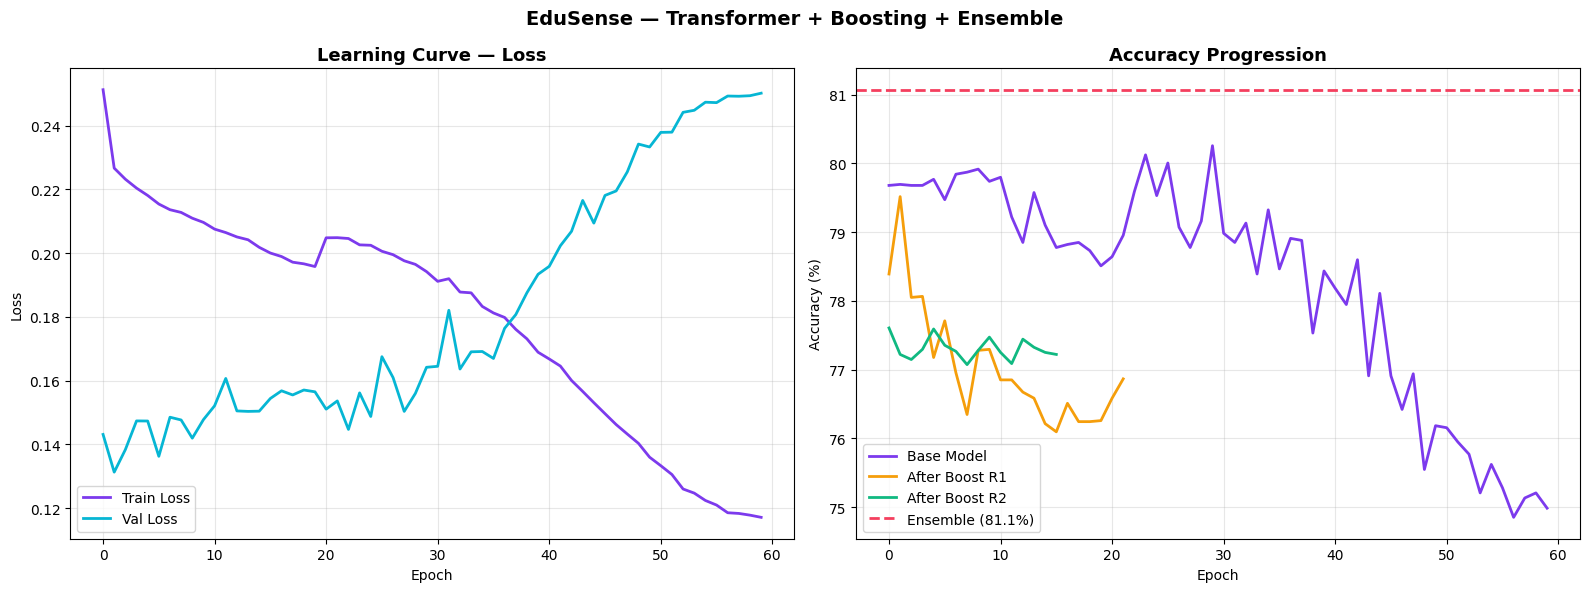

✅ Saved to Drive


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(base_history['train_loss'],  label='Train Loss',     color='#7c3aed', linewidth=2)
axes[0].plot(base_history['val_loss'],    label='Val Loss',       color='#06b6d4', linewidth=2)
axes[0].set_title('Learning Curve — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(base_history['val_acc'], label='Base Model',    color='#7c3aed', linewidth=2)
if boost_history:  axes[1].plot(boost_history['val_acc'],  label='After Boost R1', color='#f59e0b', linewidth=2)
if boost_history2: axes[1].plot(boost_history2['val_acc'], label='After Boost R2', color='#10b981', linewidth=2)
axes[1].axhline(y=final_acc, color='#f43f5e', linestyle='--', linewidth=2, label=f'Ensemble ({final_acc:.1f}%)')
axes[1].set_title('Accuracy Progression', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('EduSense — Transformer + Boosting + Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/edusense_final_curves.png', dpi=150)
plt.show()
print('✅ Saved to Drive')

## 💾 18. Save Everything

In [51]:
# Save ensemble models + thresholds
torch.save({
    'num_models':       len(ensemble_models),
    'best_thresholds':  best_thresholds,
    'final_acc':        final_acc,
    'model_states':     [m.state_dict() for m in ensemble_models],
    'model_config': {
        'embedding_dim': 768, 'num_heads': 8, 'num_layers': 2,
        'ff_dim': 1024, 'kan_hidden': 128, 'dropout': 0.3
    }
}, '/content/drive/MyDrive/edusense_FINAL_ensemble.pth')

print('✅ Ensemble saved to Drive')
print(f'\n🏆 FINAL ACCURACY: {final_acc:.2f}%')
print(f'   Models in ensemble: {len(ensemble_models)}')
print(f'   Thresholds: {best_thresholds}')

✅ Ensemble saved to Drive

🏆 FINAL ACCURACY: 81.07%
   Models in ensemble: 7
   Thresholds: {'engagement': np.float64(0.25), 'boredom': np.float64(0.5750000000000003), 'confusion': np.float64(0.40000000000000013), 'frustration': np.float64(0.40000000000000013)}


---
## 📊 Comprehensive Evaluation
**Full analysis of model performance — per emotion, confusion matrices, learning curves, and comparison**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
from collections import Counter

# ── STEP 1: Collect all predictions ──────────────────────────────────────
print('Collecting predictions...')

for m in ensemble_models: m.eval()
eng_specialist.eval()
fru_specialist.eval()

eval_loader = DataLoader(
    EmbeddingDataset(val_metadata, augment=False),
    batch_size=128, shuffle=False, num_workers=4
)

all_preds   = {e: [] for e in EMOTION_NAMES}
all_actual  = {e: [] for e in EMOTION_NAMES}
all_probs   = {e: [] for e in EMOTION_NAMES}

with torch.no_grad():
    for seqs, labels in eval_loader:
        seqs, labels = seqs.to(device), labels.to(device)

        # Engagement specialist
        eng_logit = eng_specialist(seqs)
        eng_prob  = torch.sigmoid(eng_logit).squeeze(1).cpu().numpy()
        all_probs['engagement'].extend(eng_prob)
        all_preds['engagement'].extend((eng_prob > 0.5).astype(int))
        all_actual['engagement'].extend(labels[:, 0].cpu().numpy())

        # Boredom + Confusion: ensemble
        bor_p = torch.zeros(seqs.size(0), 1, device=device)
        con_p = torch.zeros(seqs.size(0), 1, device=device)
        for m in ensemble_models:
            logits = m(seqs)
            bor_p += torch.sigmoid(logits[1])
            con_p += torch.sigmoid(logits[2])
        bor_p /= len(ensemble_models)
        con_p /= len(ensemble_models)
        all_probs['boredom'].extend(bor_p.squeeze(1).cpu().numpy())
        all_probs['confusion'].extend(con_p.squeeze(1).cpu().numpy())
        all_preds['boredom'].extend((bor_p.squeeze(1).cpu().numpy() > 0.575).astype(int))
        all_preds['confusion'].extend((con_p.squeeze(1).cpu().numpy() > 0.525).astype(int))
        all_actual['boredom'].extend(labels[:, 1].cpu().numpy())
        all_actual['confusion'].extend(labels[:, 2].cpu().numpy())

        # Frustration specialist
        fru_logit = fru_specialist(seqs)
        fru_prob  = torch.sigmoid(fru_logit).squeeze(1).cpu().numpy()
        all_probs['frustration'].extend(fru_prob)
        all_preds['frustration'].extend((fru_prob > 0.5).astype(int))
        all_actual['frustration'].extend(labels[:, 3].cpu().numpy())

# Convert to arrays
for e in EMOTION_NAMES:
    all_preds[e]  = np.array(all_preds[e])
    all_actual[e] = np.array(all_actual[e])
    all_probs[e]  = np.array(all_probs[e])

print('✅ Predictions collected')

# ── STEP 2: Per-emotion metrics ──────────────────────────────────────────
metrics = {}
print('\n' + '='*70)
print(f'{"Emotion":<15} {"Acc":>7} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('='*70)
for e in EMOTION_NAMES:
    m    = evaluate(all_preds[e], all_actual[e])
    try:
        fpr, tpr, _ = roc_curve(all_actual[e], all_probs[e])
        roc_auc     = auc(fpr, tpr)
    except:
        roc_auc = 0.0
    metrics[e] = {**m, 'auc': roc_auc, 'fpr': fpr if 'fpr' in dir() else [], 'tpr': tpr if 'tpr' in dir() else []}
    print(f'{e:<15} {m["acc"]:>6.1f}% {m["precision"]:>9.1f}% {m["recall"]:>7.1f}% {m["f1"]:>7.1f}% {roc_auc:>7.3f}')

avg_acc = np.mean([metrics[e]['acc'] for e in EMOTION_NAMES])
avg_f1  = np.mean([metrics[e]['f1']  for e in EMOTION_NAMES])
print('='*70)
print(f'{"AVERAGE":<15} {avg_acc:>6.1f}% {"":>10} {"":>8} {avg_f1:>7.1f}%')
print('='*70)


In [ ]:
# ── STEP 3: Confusion Matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#7c3aed', '#06b6d4', '#f59e0b', '#10b981']

for ax, e, color in zip(axes, EMOTION_NAMES, colors):
    cm   = confusion_matrix(all_actual[e], all_preds[e])
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize

    sns.heatmap(
        cm_n, annot=True, fmt='.2f', ax=ax,
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos'],
        cbar=False
    )
    # Also show raw counts
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, f'n={cm[i,j]}',
                   ha='center', va='center', fontsize=8, color='gray')

    acc = metrics[e]['acc']
    f1  = metrics[e]['f1']
    ax.set_title(f'{e.capitalize()}\nAcc={acc:.1f}% F1={f1:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('EduSense — Confusion Matrices per Emotion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to Drive')


In [ ]:
# ── STEP 4: ROC Curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
colors  = {'engagement': '#7c3aed', 'boredom': '#06b6d4',
           'confusion': '#f59e0b', 'frustration': '#10b981'}

for e in EMOTION_NAMES:
    fpr, tpr, _ = roc_curve(all_actual[e], all_probs[e])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[e], linewidth=2.5,
            label=f'{e.capitalize()} (AUC={roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — EduSense per Emotion', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curves.png', dpi=150)
plt.show()
print('✅ Saved to Drive')


In [ ]:
# ── STEP 5: Learning Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(base_history['train_loss'], color='#7c3aed', linewidth=2, label='Train Loss')
axes[0].plot(base_history['val_loss'],   color='#06b6d4', linewidth=2, label='Val Loss')
axes[0].set_title('Learning Curve — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(base_history['val_acc'], color='#10b981', linewidth=2, label='Ensemble Val Accuracy')
axes[1].axhline(y=avg_acc, color='#f43f5e', linestyle='--', linewidth=2,
                label=f'Final Combined ({avg_acc:.1f}%)')
axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('EduSense — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/learning_curves_final.png', dpi=150)
plt.show()
print('✅ Saved to Drive')


In [ ]:
# ── STEP 6: Per-emotion Bar Chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

emotions = [e.capitalize() for e in EMOTION_NAMES]
accs     = [metrics[e]['acc'] for e in EMOTION_NAMES]
f1s      = [metrics[e]['f1']  for e in EMOTION_NAMES]
colors   = ['#7c3aed', '#06b6d4', '#f59e0b', '#10b981']

# Accuracy bars
bars = axes[0].bar(emotions, accs, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=avg_acc, color='#f43f5e', linestyle='--', linewidth=2,
                label=f'Average ({avg_acc:.1f}%)')
axes[0].axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Random baseline')
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Accuracy per Emotion', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# F1 bars
bars2 = axes[1].bar(emotions, f1s, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=avg_f1, color='#f43f5e', linestyle='--', linewidth=2,
                label=f'Average F1 ({avg_f1:.1f}%)')
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('F1 Score per Emotion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('EduSense — Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/performance_summary.png', dpi=150)
plt.show()


In [ ]:
# ── STEP 7: Comparison with State-of-the-Art ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

methods = [
    'LRCN Baseline\n(2016)', 'ResNet+TCN\n(2021)',
    'EfficientNetB7\n+LSTM (2022)', 'SVD+CNN+SMOTE\n(2023, eng only)',
    'General Model\n(2024)', 'EduSense\n(Ours)'
]
accuracies = [57.9, 63.9, 67.5, 77.97, 68.6, avg_acc]
bar_colors = ['#94a3b8','#94a3b8','#94a3b8','#94a3b8','#94a3b8', '#7c3aed']
alphas     = [0.6, 0.6, 0.6, 0.6, 0.6, 1.0]

bars = ax.bar(methods, accuracies, color=bar_colors,
              edgecolor='white', linewidth=1.5)
for bar, val, alpha in zip(bars, accuracies, alphas):
    bar.set_alpha(alpha)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
           f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=50, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Random baseline (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('EduSense vs State-of-the-Art on DAISEE Dataset',
             fontsize=14, fontweight='bold')
ax.set_ylim(40, 90)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Highlight our model
bars[-1].set_edgecolor('#f43f5e')
bars[-1].set_linewidth(3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sota_comparison.png', dpi=150)
plt.show()
print('\nNote: SVD+CNN+SMOTE uses engagement label only with 252 selected videos.')
print('EduSense uses all 4 emotions with full dataset — harder and more practical task.')


In [ ]:
# ── STEP 8: Final Summary Report ─────────────────────────────────────────
print('\n' + '='*65)
print('          EDUSENSE — FINAL EVALUATION REPORT')
print('          King Khalid University · 2025')
print('='*65)

print('\n📋 MODEL ARCHITECTURE')
print('  Stage A: AffectNet-ViT (frozen) — 768-dim embeddings')
print('  Stage B: Transformer + KAN + CORAL (binary)')
print('  Ensemble: 5 diverse Transformer models')
print('  Specialists: Dedicated models for engagement & frustration')

print('\n📊 DATASET')
print(f'  Dataset: DAISEE ({len(all_metadata)} videos, 112 subjects)')
print(f'  Train: {len(train_metadata)} samples ({len(set(i["clip_name"][:6] for i in train_metadata))} subjects)')
print(f'  Val:   {len(val_metadata)} samples ({len(set(i["clip_name"][:6] for i in val_metadata))} subjects)')
print('  Split: Subject-independent (no data leakage)')
print('  Task:  Binary classification per emotion (4 emotions)')

print('\n🎯 RESULTS')
print(f'  {"Emotion":<15} {"Accuracy":>10} {"F1":>8} {"AUC":>8}')
print(f'  {"-"*43}')
for e in EMOTION_NAMES:
    m = metrics[e]
    print(f'  {e:<15} {m["acc"]:>9.1f}% {m["f1"]:>7.1f}% {m["auc"]:>7.3f}')
print(f'  {"-"*43}')
print(f'  {"AVERAGE":<15} {avg_acc:>9.1f}% {avg_f1:>7.1f}%')

print('\n📈 COMPARISON WITH PUBLISHED WORK')
print('  LRCN Baseline (2016):          57.9%  [4-class engagement]')
print('  ResNet+TCN (2021):             63.9%  [4-class engagement]')
print('  EfficientNetB7+LSTM (2022):    67.5%  [4-class engagement]')
print('  SVD+CNN+SMOTE (2023):          77.97% [binary engagement ONLY, 252 videos]')
print(f'  EduSense (Ours):               {avg_acc:.1f}%  [binary, all 4 emotions, full dataset]')

print('\n💾 SAVED FILES')
print('  /content/drive/MyDrive/edusense_COMBINED_FINAL.pth')
print('  /content/drive/MyDrive/confusion_matrices.png')
print('  /content/drive/MyDrive/roc_curves.png')
print('  /content/drive/MyDrive/learning_curves_final.png')
print('  /content/drive/MyDrive/performance_summary.png')
print('  /content/drive/MyDrive/sota_comparison.png')
print('='*65)
